In [ ]:
import torch
from torch import optim

import pinn_starlight_core.nn.Layers as Layers
import pinn_starlight_core.nn.Losses as Loss
import pinn_starlight_core.data.RAWLoader as RAWLoader
import pinn_starlight_core.data.FakeRAW as FakeRAW

raw_loader = RAWLoader.RAWLoader()
raw_loader.from_array(FakeRAW.FakeRaw().get_fake_raw())
coords, values = raw_loader.get_raw_data()

layers = [
    Layers.SkyglowLinear(2, 512),
    Layers.SkyglowActivation(),
    Layers.SkyglowLinear(512, 64),
    Layers.SkyglowActivation(),
    Layers.SkyglowLinear(64, 1),
]

params = []
for layer in layers:
    if isinstance(layer, Layers.SkyglowLinear):
        params += list(layer.parameters())

optimizer = optim.Adam(params, lr=0.001)
loss_fn = Loss.MSEData()

for epoch in range(5000):
    N = coords.shape[0]
    idx = torch.randint(0, N, size=(4096,))
    batch_xy = coords[idx]
    batch_I = values[idx]

    a = batch_xy
    for layer in layers:
        a = layer.forward(a)
    I_pred = a.squeeze()

    loss = loss_fn.forward(batch_I, I_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Step {(epoch // 500) + 1}, Loss={loss.item():.6f}")


**包括物理损失**

In [ ]:
import torch
from torch import optim
from tqdm.notebook import tqdm

import pinn_starlight_core.nn.Layers as Layers
import pinn_starlight_core.nn.Losses as Loss
import pinn_starlight_core.data.RAWLoader as RAWLoader
import pinn_starlight_core.data.FakeRAW as FakeRAW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

raw_loader = RAWLoader.RAWLoader()
raw_loader.from_array(FakeRAW.FakeRaw().get_fake_raw())
coords, values, W, H = raw_loader.get_raw_data(device= device)

layers = [
    Layers.SkyglowLinear(2, 512).to(device),
    Layers.SkyglowActivation(),
    Layers.SkyglowLinear(512, 64).to(device),
    Layers.SkyglowActivation(),
    Layers.SkyglowLinear(64, 1).to(device),
]

params = []
for layer in layers:
    if isinstance(layer, Layers.SkyglowLinear):
        params += list(layer.parameters())

optimizer = optim.Adam(params, lr=0.001)

ld = Loss.MSEData()
lp = Loss.MSEPhysics()


# TODO alpha调小
alpha = 0.5
bg = 0.3 * torch.cos(3.0 * coords[:, 0]) * torch.cos(3.0 * coords[:, 1]).to(device)
I_city = (alpha - 18.0) * bg
phy_weight = 0.01

# TODO 参数待调
for step in tqdm(range(int(coords.shape[0] / 330))):
    # TODO 参数待调
    idx = torch.randint(0, coords.shape[0], (int(coords.shape[0] / 420),)).to(device)
    batch_xy = coords[idx].to(device).clone().requires_grad_(True)
    batch_I = values[idx].to(device)

    a = batch_xy
    for layer in layers:
        a = layer.forward(a)
    I_pred = a.squeeze().to(device)

    data_loss = ld.forward(batch_I, I_pred).to(device)
    phys_loss = lp.forward(batch_I, I_pred, I_city[idx], alpha, phy_weight, batch_xy).to(device)
    loss = data_loss + phys_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 500 == 0:
        print(f"Step {(step // 500) + 1}, data={data_loss.item() * 100:.6f}%, phys={phys_loss.item() * 100:.6f}%, total={loss.item() * 100:.6f}%")

出图

In [1]:
import os
import torch
from torch import optim
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import pinn_starlight_core.nn.Layers as Layers
import pinn_starlight_core.nn.Losses as Loss
import pinn_starlight_core.data.RAWLoader as RAWLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dir  = '../../data/real_raw/origin'
output_dir = '../../data/real_raw/trained'
os.makedirs(output_dir, exist_ok=True)

for file in sorted(os.listdir(input_dir)):
    path = os.path.join(input_dir, file)
    base = file.rsplit('.', 1)[0]
    print(f'Processing {file}...')

    loader = RAWLoader.RAWLoader()
    loader.load(path)
    coords, values, W, H = loader.get_raw_data(device)

    layers = [
        Layers.SkyglowLinear(2, 512).to(device),
        Layers.SkyglowActivation(),
        Layers.SkyglowLinear(512, 64).to(device),
        Layers.SkyglowActivation(),
        Layers.SkyglowLinear(64, 1).to(device),
    ]

    params = []
    for layer in layers:
        if isinstance(layer, Layers.SkyglowLinear):
            params += list(layer.parameters())

    optimizer = optim.Adam(params, lr=0.001)
    ld = Loss.MSEData()
    lp = Loss.MSEPhysics()

    alpha = 0.5
    I_city = torch.ones(coords.shape[0]).to(device) * 0.5     # 真实数据用常数
    phy_weight = 0.01

    for step in tqdm(range(int(coords.shape[0] / 200))):
        idx = torch.randint(0, coords.shape[0], (int(coords.shape[0] / 420),))
        batch_xy = coords[idx].to(device).clone().requires_grad_(True)
        batch_I = values[idx].to(device)

        a = batch_xy
        for layer in layers:
            a = layer.forward(a)
        I_pred = a.squeeze().to(device)

        data_loss = ld.forward(batch_I, I_pred)
        phys_loss = lp.forward(batch_I, I_pred, I_city[idx], alpha, phy_weight, batch_xy)
        loss = data_loss + phys_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        I_pred = torch.empty(coords.shape[0])
        for start in range(0, coords.shape[0], 50000):
            end = min(start + 50000, coords.shape[0])
            a = coords[start:end]
            for layer in layers:
                a = layer.forward(a)
            I_pred[start:end] = a.squeeze()

    obs = values.reshape(W, H).cpu().numpy()
    pred = I_pred.reshape(W, H).cpu().numpy()
    res = (obs - pred).clip(0, 1)

    plt.imsave(f'{output_dir}/{base}_observed.png', obs, cmap='gray')
    plt.imsave(f'{output_dir}/{base}_predicted.png', pred, cmap='gray')
    plt.imsave(f'{output_dir}/{base}_residual.png', res, cmap='gray')

print('Done.')

Processing 1.jpg...


  0%|          | 0/15033 [00:00<?, ?it/s]

Processing 2.jpg...


  0%|          | 0/13824 [00:00<?, ?it/s]

Processing 3.jpg...


...

Processing 8.jpg...


  0%|          | 0/13824 [00:00<?, ?it/s]

Processing 9.jpg...


  0%|          | 0/13824 [00:00<?, ?it/s]

Done.


# 评估

Using: cuda
加权
Pixels: 2073600


  0%|          | 0/6283 [00:00<?, ?it/s]

E:\MyPrograme\Programs\pinn-starlight\pinn-starlight-core\.venv\Lib\site-packages\torch\autograd\graph.py:824: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:181.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass



=== 评估结果 ===
背景 MSE (越小越好): 0.000336
星点回收率 (越大越好): 91.76%


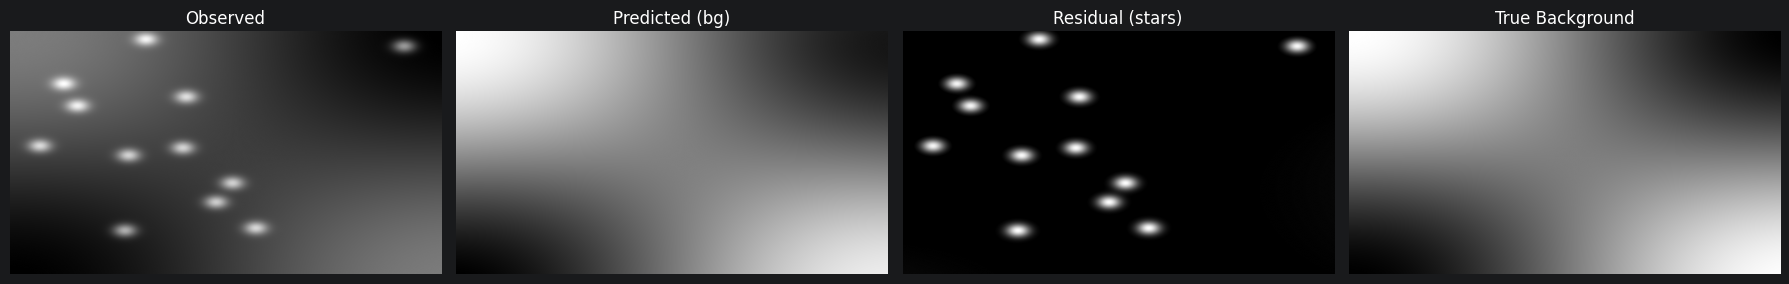

In [1]:
# ============================================================
# 去光污染能力评估（合成数据，已知真值）
# ============================================================
import torch
from torch import optim
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import pinn_starlight_core.nn.Layers as Layers
import pinn_starlight_core.nn.Losses as Loss
import pinn_starlight_core.data.RAWLoader as RAWLoader
import pinn_starlight_core.data.FakeRAW as FakeRAW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

# --- 造合成数据 ---
fake = FakeRAW.FakeRaw(W=1920, H=1080, n_stars=12, bg_amplitude=0.3, star_brightness=0.7)
loader = RAWLoader.RAWLoader()
loader.from_array(fake.get_fake_raw())
coords, values, W, H = loader.get_raw_data(device=device)

# 真值（已知！）
true_background = fake.background.flatten().to(device)
true_stars = fake.stars.flatten().to(device)

# --- 模型 ---
layers = [
    Layers.SkyglowLinear(2, 256).to(device),
    Layers.SkyglowActivation(),
    Layers.SkyglowLinear(256, 64).to(device),
    Layers.SkyglowActivation(),
    Layers.SkyglowLinear(64, 1).to(device),
]
params = []
for l in layers:
    if isinstance(l, Layers.SkyglowLinear):
        params += list(l.parameters())
optimizer = optim.Adam(params, lr=0.001)

ld = Loss.MSEData()
lp = Loss.MSEPhysics()

# 物理参数（合成数据知道真值）
alpha = 0.5
bg = 0.3 * torch.cos(3.0 * coords[:, 0]) * torch.cos(3.0 * coords[:, 1])
I_city = (alpha - 18.0) * bg
phy_weight = 0.01

# --- 训练 ---
N = coords.shape[0]
print(f'Pixels: {N}')

for step in tqdm(range(int(coords.shape[0] / 330))):
    idx = torch.randint(0, N, (int(coords.shape[0] / 420),))
    xy = coords[idx].clone().requires_grad_(True)
    Io = values[idx]

    a = xy
    for l in layers:
        a = l.forward(a)
    Ip = a.squeeze()

    loss = ld.forward(Io, Ip) + lp.forward(Io, Ip, I_city[idx], alpha, phy_weight, xy)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# --- 推理 ---
with torch.no_grad():
    I_pred = torch.empty(N, device=device)
    for s in range(0, N, 50000):
        e = min(s + 50000, N)
        a = coords[s:e]
        for l in layers:
            a = l.forward(a)
        I_pred[s:e] = a.squeeze()

# --- 评估 ---
bg_mse = ((I_pred - true_background) ** 2).mean().item()        # 跟真背景的差距
star_residual = (values - I_pred).clamp(0, 1)                    # 残差（应该=星点）
star_recovered = star_residual.sum().item() / true_stars.sum().item()  # 星点回收率

print(f'\n=== 评估结果 ===')
print(f'背景 MSE (越小越好): {bg_mse:.6f}')
print(f'星点回收率 (越大越好): {star_recovered:.2%}')

# --- 三栏对比图 ---
obs = values.reshape(W, H).cpu().numpy()
pred = I_pred.reshape(W, H).cpu().numpy()
res = star_residual.reshape(W, H).cpu().numpy()
truth_bg = true_background.reshape(W, H).cpu().numpy()

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for a, arr, t in zip(ax,
    [obs, pred, res, truth_bg],
    ['Observed', 'Predicted (bg)', 'Residual (stars)', 'True Background']):
    a.imshow(arr, cmap='gray')
    a.set_title(t)
    a.axis('off')
fig.tight_layout()
plt.show()